# CSQA Layer-Output And Internal-State Noising Analysis

- model family: Qwen2.5
- target checkpoint: 3B instruct model
- intervention class: additive noise on internal states
- decision space: constrained A-E answer-choice logits only

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.data.load_csqa import load_csqa

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

/home/ubuntu/Transformer-Decision-Traces/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [ ]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
EVAL_SPLIT = "validation"
EVAL_LIMIT = 300
MAX_SEQ_LEN = 384
CLEAN_BATCH_SIZE = 4
INTERVENTION_BATCH_SIZE = 2
MAIN_NOISE_SCALE = 0.25
DOSE_RESPONSE_SCALES = [0.05, 0.10, 0.25, 0.50]
SEED = 42
USE_BFLOAT16_IF_AVAILABLE = True

## Data And Model Setup


In [3]:
torch.manual_seed(SEED)
np.random.seed(SEED)

LETTERS = ["A", "B", "C", "D", "E"]

eval_rows = load_csqa(split=EVAL_SPLIT, limit=EVAL_LIMIT).copy()
eval_rows["n_choices"] = eval_rows["csqa_choices"].map(len)
eval_rows["prompt_len_chars"] = eval_rows["text"].str.len()
assert eval_rows["n_choices"].eq(5).all(), "Expected 5 choices for every CSQA row."

if torch.cuda.is_available():
    if USE_BFLOAT16_IF_AVAILABLE and torch.cuda.is_bf16_supported():
        model_dtype = torch.bfloat16
    else:
        model_dtype = torch.float16
    device_map = "auto"
else:
    model_dtype = torch.float32
    device_map = None

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=model_dtype,
    device_map=device_map,
    attn_implementation="eager",
)
model.eval()


def build_answer_token_ids(tok):
    out = {}
    for letter in LETTERS:
        ids = tok(" " + letter, add_special_tokens=False)["input_ids"]
        if len(ids) != 1:
            raise ValueError(f"Answer token '{letter}' is not single-token: {ids}")
        out[letter] = int(ids[0])
    return out


answer_token_ids = build_answer_token_ids(tok)
answer_ids = [answer_token_ids[l] for l in LETTERS]
answer_id_tensor = torch.tensor(answer_ids, dtype=torch.long)

display(eval_rows[["example_id", "answerKey", "prompt_len_chars"]].head())
print("eval rows:", len(eval_rows))
print("answer token ids:", answer_token_ids)


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:48<00:00,  8.96it/s]


,example_id,answerKey,prompt_len_chars
0,701fac8b8c04ab56c4394b2e7b2aa8df,A,187
1,1db37ef1b4ebdcbc12a7d7dec87472a8,A,145
2,a5cb28d53c4cd35c06fbbbb3dbf6aaa8,B,149
3,ce6c00c4f3edcd54ab4fa1e3a8582e7c,A,141
4,054aade2878f1bd189aa590565583d91,A,158


eval rows: 1221
answer token ids: {'A': 362, 'B': 425, 'C': 356, 'D': 422, 'E': 468}


## Helper Functions


In [4]:
def get_decoder_layers(model):
    candidates = [
        "model.layers",
        "transformer.h",
        "gpt_neox.layers",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    raise ValueError("Could not locate decoder layers on this model.")


def encode_prompts(texts, tok, max_seq_len):
    batch = tok(
        list(texts),
        add_special_tokens=False,
        truncation=True,
        max_length=max_seq_len,
        padding=True,
        return_tensors="pt",
    )
    pos = []
    for mask in batch["attention_mask"]:
        nz = torch.nonzero(mask, as_tuple=False).view(-1)
        pos.append(int(nz[-1].item()))
    batch["decision_pos"] = torch.tensor(pos, dtype=torch.long)
    return batch


def compute_choice_metrics(choice_logits, true_choice_idx):
    pred_idx = choice_logits.argmax(dim=-1)
    row_idx = torch.arange(choice_logits.shape[0], device=choice_logits.device)
    true_logits = choice_logits[row_idx, true_choice_idx]
    other_logits = choice_logits.clone()
    other_logits[row_idx, true_choice_idx] = -torch.inf
    best_other = other_logits.max(dim=-1).values
    correct_margin = true_logits - best_other
    return pred_idx.detach().cpu(), correct_margin.detach().cpu()


def apply_token_noise(hidden, decision_pos, noise_scale):
    row_idx = torch.arange(hidden.shape[0], device=hidden.device)
    token_hidden = hidden[row_idx, decision_pos]
    rms = token_hidden.float().pow(2).mean(dim=-1, keepdim=True).sqrt().to(token_hidden.dtype)
    noise = torch.randn_like(token_hidden) * (noise_scale * rms)
    hidden_out = hidden.clone()
    hidden_out[row_idx, decision_pos] = token_hidden + noise
    return hidden_out


def intervention_summary(df, group_cols):
    summary_all = (
        df.groupby(group_cols)
        .agg(
            mean_correct_margin_delta=("correct_margin_delta", "mean"),
            prediction_preservation_rate=("prediction_preserved", "mean"),
            noised_accuracy=("noised_is_correct", "mean"),
        )
    )

    summary_clean_correct = (
        df.loc[df["clean_is_correct"]]
        .groupby(group_cols)
        .agg(
            clean_correct_break_rate=("clean_correct_broken", "mean"),
            noised_accuracy_on_clean_correct=("noised_is_correct", "mean"),
        )
    )

    return summary_all.join(summary_clean_correct, how="left").reset_index()


decoder_layers = get_decoder_layers(model)
L = len(decoder_layers)
answer_ids_on_device = answer_id_tensor.to(model.lm_head.weight.device)

substep_display_names = {
    "pre_attn": "Pre-attention residual state",
    "post_attn": "Post-attention residual state",
    "post_mlp": "Post-feed-forward residual state",
}

component_display_names = {
    "attention_output": "Attention output",
    "feed_forward_output": "Feed-forward output",
}

print("decoder layers:", L)


decoder layers: 36


## Clean Baseline

Final answer-choice outputs without intervention.


In [5]:
def extract_clean_baseline(frame):
    rows = []

    for start in tqdm(range(0, len(frame), CLEAN_BATCH_SIZE), total=int(math.ceil(len(frame) / CLEAN_BATCH_SIZE)), desc="clean baseline"):
        batch_df = frame.iloc[start:start + CLEAN_BATCH_SIZE].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(model.device)
        true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

        with torch.no_grad():
            out = model(**batch, return_dict=True, use_cache=False)

        row_idx = torch.arange(len(batch_df), device=decision_pos.device)
        final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
        pred_idx, correct_margin = compute_choice_metrics(final_logits, true_choice_idx)
        clean_is_correct = pred_idx.eq(true_choice_idx.detach().cpu())

        for bi in range(len(batch_df)):
            rows.append(
                {
                    "example_id": batch_df.loc[bi, "example_id"],
                    "true_choice_idx": int(true_choice_idx[bi].item()),
                    "clean_prediction_idx": int(pred_idx[bi].item()),
                    "clean_prediction": LETTERS[int(pred_idx[bi].item())],
                    "clean_correct_margin": float(correct_margin[bi].item()),
                    "clean_is_correct": bool(clean_is_correct[bi].item()),
                }
            )

    return pd.DataFrame(rows)


clean_df = extract_clean_baseline(eval_rows)
analysis_df = eval_rows.merge(clean_df, on="example_id", how="left", validate="one_to_one")

display(
    analysis_df[["example_id", "answerKey", "clean_prediction", "clean_correct_margin", "clean_is_correct"]].head()
)
print("clean accuracy:", round(float(analysis_df["clean_is_correct"].mean()), 4))

clean baseline: 100%|██████████| 306/306 [00:15<00:00, 19.50it/s]


,example_id,answerKey,clean_prediction,clean_correct_margin,clean_is_correct
0,701fac8b8c04ab56c4394b2e7b2aa8df,A,D,-1.500,False
1,1db37ef1b4ebdcbc12a7d7dec87472a8,A,A,9.625,True
2,a5cb28d53c4cd35c06fbbbb3dbf6aaa8,B,B,10.625,True
3,ce6c00c4f3edcd54ab4fa1e3a8582e7c,A,A,14.000,True
4,054aade2878f1bd189aa590565583d91,A,D,-8.125,False


clean accuracy: 0.8026


## Layer-Output Noising

Noise is injected at the output of one decoder layer at a time. Only the decision-position token is modified.


In [6]:
def run_layer_output_noising_scan(frame, noise_scale, desc):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc=desc):
        torch.manual_seed(SEED + target_layer)
        current_state = {}

        def noise_hook(module, args, output):
            hidden = output[0] if isinstance(output, tuple) else output
            hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
            if isinstance(output, tuple):
                return (hidden_out,) + output[1:]
            return hidden_out

        handle = decoder_layers[target_layer].register_forward_hook(noise_hook)

        try:
            for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                decision_pos = batch_cpu.pop("decision_pos")
                batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                decision_pos = decision_pos.to(model.device)
                true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                current_state["decision_pos"] = decision_pos

                with torch.no_grad():
                    out = model(**batch, return_dict=True, use_cache=False)

                row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                pred_idx, correct_margin = compute_choice_metrics(final_logits, true_choice_idx)
                noised_is_correct = pred_idx.eq(true_choice_idx.detach().cpu())

                for bi in range(len(batch_df)):
                    rows.append(
                        {
                            "example_id": batch_df.loc[bi, "example_id"],
                            "target_layer": int(target_layer),
                            "noise_scale": float(noise_scale),
                            "noised_prediction_idx": int(pred_idx[bi].item()),
                            "noised_prediction": LETTERS[int(pred_idx[bi].item())],
                            "noised_correct_margin": float(correct_margin[bi].item()),
                            "noised_is_correct": bool(noised_is_correct[bi].item()),
                        }
                    )
        finally:
            handle.remove()

    return pd.DataFrame(rows)


layer_output_df = run_layer_output_noising_scan(eval_rows, MAIN_NOISE_SCALE, "layer-output noising")
layer_output_df = layer_output_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_correct_margin", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
layer_output_df["prediction_preserved"] = layer_output_df["noised_prediction_idx"].eq(layer_output_df["clean_prediction_idx"])
layer_output_df["correct_margin_delta"] = layer_output_df["noised_correct_margin"] - layer_output_df["clean_correct_margin"]
layer_output_df["clean_correct_broken"] = layer_output_df["clean_is_correct"] & (~layer_output_df["noised_is_correct"])

layer_output_summary = intervention_summary(layer_output_df, ["target_layer"])
layer_output_summary["layer_index_1based"] = layer_output_summary["target_layer"] + 1

display(layer_output_summary.round(4))

layer-output noising: 100%|██████████| 36/36 [14:41<00:00, 24.49s/it]


,target_layer,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based
0,0,-0.1406,0.9713,0.8002,0.0163,0.9837,1
1,1,-0.0940,0.9722,0.7993,0.0153,0.9847,2
2,2,-0.0967,0.9754,0.8043,0.0112,0.9888,3
3,3,-0.0886,0.9771,0.8059,0.0082,0.9918,4
4,4,-0.0321,0.9746,0.8018,0.0143,0.9857,5
5,5,-0.0626,0.9771,0.8043,0.0082,0.9918,6
6,6,-0.0254,0.9754,0.8010,0.0122,0.9878,7
7,7,-0.0460,0.9746,0.8034,0.0122,0.9878,8
8,8,0.0497,0.9803,0.8034,0.0092,0.9908,9
9,9,-0.0016,0.9779,0.8026,0.0112,0.9888,10


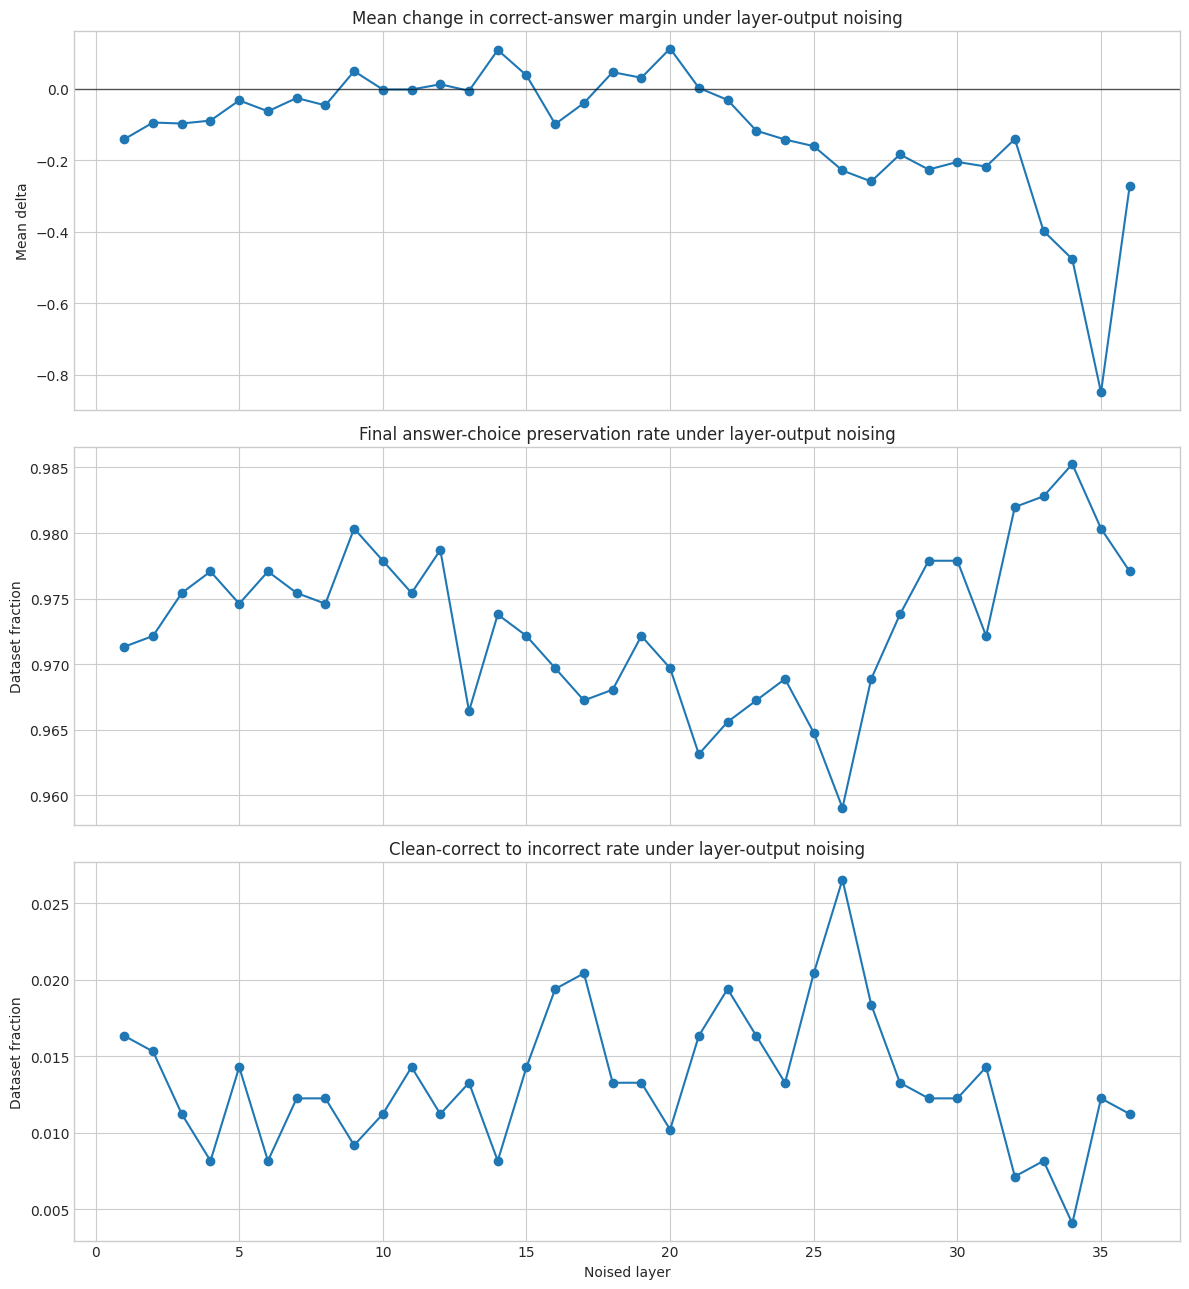

In [7]:
layers_1based = layer_output_summary["layer_index_1based"].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 13), sharex=True)

axes[0].plot(layers_1based, layer_output_summary["mean_correct_margin_delta"], marker="o")
axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Mean change in correct-answer margin under layer-output noising")

axes[1].plot(layers_1based, layer_output_summary["prediction_preservation_rate"], marker="o")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Final answer-choice preservation rate under layer-output noising")

axes[2].plot(layers_1based, layer_output_summary["clean_correct_break_rate"], marker="o")
axes[2].set_xlabel("Noised layer")
axes[2].set_ylabel("Dataset fraction")
axes[2].set_title("Clean-correct to incorrect rate under layer-output noising")

plt.tight_layout()
plt.show()

In [8]:
display(
    layer_output_summary.sort_values(
        ["clean_correct_break_rate", "mean_correct_margin_delta"],
        ascending=[False, True],
    )[[
        "layer_index_1based",
        "mean_correct_margin_delta",
        "prediction_preservation_rate",
        "noised_accuracy",
        "clean_correct_break_rate",
        "noised_accuracy_on_clean_correct",
    ]]
    .head(10)
    .round(4)
)

,layer_index_1based,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct
25,26,-0.2282,0.9590,0.7903,0.0265,0.9735
24,25,-0.1601,0.9648,0.7985,0.0204,0.9796
16,17,-0.0395,0.9672,0.7952,0.0204,0.9796
15,16,-0.0984,0.9697,0.7944,0.0194,0.9806
21,22,-0.0308,0.9656,0.7969,0.0194,0.9806
26,27,-0.2589,0.9689,0.7952,0.0184,0.9816
0,1,-0.1406,0.9713,0.8002,0.0163,0.9837
22,23,-0.1168,0.9672,0.8010,0.0163,0.9837
20,21,0.0030,0.9631,0.8010,0.0163,0.9837
1,2,-0.0940,0.9722,0.7993,0.0153,0.9847


## Substep Noising

Noise is injected at one internal residual-state checkpoint at a time.

- pre-attention residual state
- post-attention residual state
- post-feed-forward residual state


In [9]:
def run_substep_noising_scan(frame, noise_scale):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc="substep noising"):
        for substep_idx, target_substep in enumerate(["pre_attn", "post_attn", "post_mlp"]):
            torch.manual_seed(SEED + 1000 * (target_layer + 1) + substep_idx)
            current_state = {}

            if target_substep == "pre_attn":
                def hook_fn(module, args):
                    hidden = args[0]
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    return (hidden_out,) + args[1:]

                handle = decoder_layers[target_layer].register_forward_pre_hook(hook_fn)

            elif target_substep == "post_attn":
                def hook_fn(module, args):
                    hidden = args[0]
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    return (hidden_out,) + args[1:]

                if not hasattr(decoder_layers[target_layer], "post_attention_layernorm"):
                    raise ValueError("Expected post_attention_layernorm on decoder layer.")
                handle = decoder_layers[target_layer].post_attention_layernorm.register_forward_pre_hook(hook_fn)

            else:
                def hook_fn(module, args, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    if isinstance(output, tuple):
                        return (hidden_out,) + output[1:]
                    return hidden_out

                handle = decoder_layers[target_layer].register_forward_hook(hook_fn)

            try:
                for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                    batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                    decision_pos = batch_cpu.pop("decision_pos")
                    batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                    decision_pos = decision_pos.to(model.device)
                    true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                    current_state["decision_pos"] = decision_pos

                    with torch.no_grad():
                        out = model(**batch, return_dict=True, use_cache=False)

                    row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                    final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                    pred_idx, correct_margin = compute_choice_metrics(final_logits, true_choice_idx)
                    noised_is_correct = pred_idx.eq(true_choice_idx.detach().cpu())

                    for bi in range(len(batch_df)):
                        rows.append(
                            {
                                "example_id": batch_df.loc[bi, "example_id"],
                                "target_layer": int(target_layer),
                                "target_substep": target_substep,
                                "noise_scale": float(noise_scale),
                                "noised_prediction_idx": int(pred_idx[bi].item()),
                                "noised_prediction": LETTERS[int(pred_idx[bi].item())],
                                "noised_correct_margin": float(correct_margin[bi].item()),
                                "noised_is_correct": bool(noised_is_correct[bi].item()),
                            }
                        )
            finally:
                handle.remove()

    return pd.DataFrame(rows)


substep_df = run_substep_noising_scan(eval_rows, MAIN_NOISE_SCALE)
substep_df = substep_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_correct_margin", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
substep_df["prediction_preserved"] = substep_df["noised_prediction_idx"].eq(substep_df["clean_prediction_idx"])
substep_df["correct_margin_delta"] = substep_df["noised_correct_margin"] - substep_df["clean_correct_margin"]
substep_df["clean_correct_broken"] = substep_df["clean_is_correct"] & (~substep_df["noised_is_correct"])

substep_summary = intervention_summary(substep_df, ["target_layer", "target_substep"])
substep_summary["layer_index_1based"] = substep_summary["target_layer"] + 1
substep_summary["target_substep_label"] = substep_summary["target_substep"].map(substep_display_names)

display(substep_summary.head(12).round(4))


substep noising: 100%|██████████| 36/36 [44:09<00:00, 73.59s/it]


,target_layer,target_substep,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based,target_substep_label
0,0,post_attn,-0.1454,0.9754,0.8018,0.0122,0.9878,1,Post-attention residual state
1,0,post_mlp,-0.1122,0.9754,0.8018,0.0102,0.9898,1,Post-feed-forward residual state
2,0,pre_attn,0.1386,0.9820,0.8043,0.0071,0.9929,1,Pre-attention residual state
3,1,post_attn,-0.0822,0.9795,0.8002,0.0102,0.9898,2,Post-attention residual state
4,1,post_mlp,-0.0882,0.9754,0.8010,0.0122,0.9878,2,Post-feed-forward residual state
5,1,pre_attn,-0.1155,0.9738,0.8018,0.0122,0.9878,2,Pre-attention residual state
6,2,post_attn,0.0221,0.9844,0.8034,0.0061,0.9939,3,Post-attention residual state
7,2,post_mlp,-0.1257,0.9787,0.8051,0.0092,0.9908,3,Post-feed-forward residual state
8,2,pre_attn,-0.0716,0.9754,0.8059,0.0082,0.9918,3,Pre-attention residual state
9,3,post_attn,-0.0586,0.9828,0.7985,0.0102,0.9898,4,Post-attention residual state


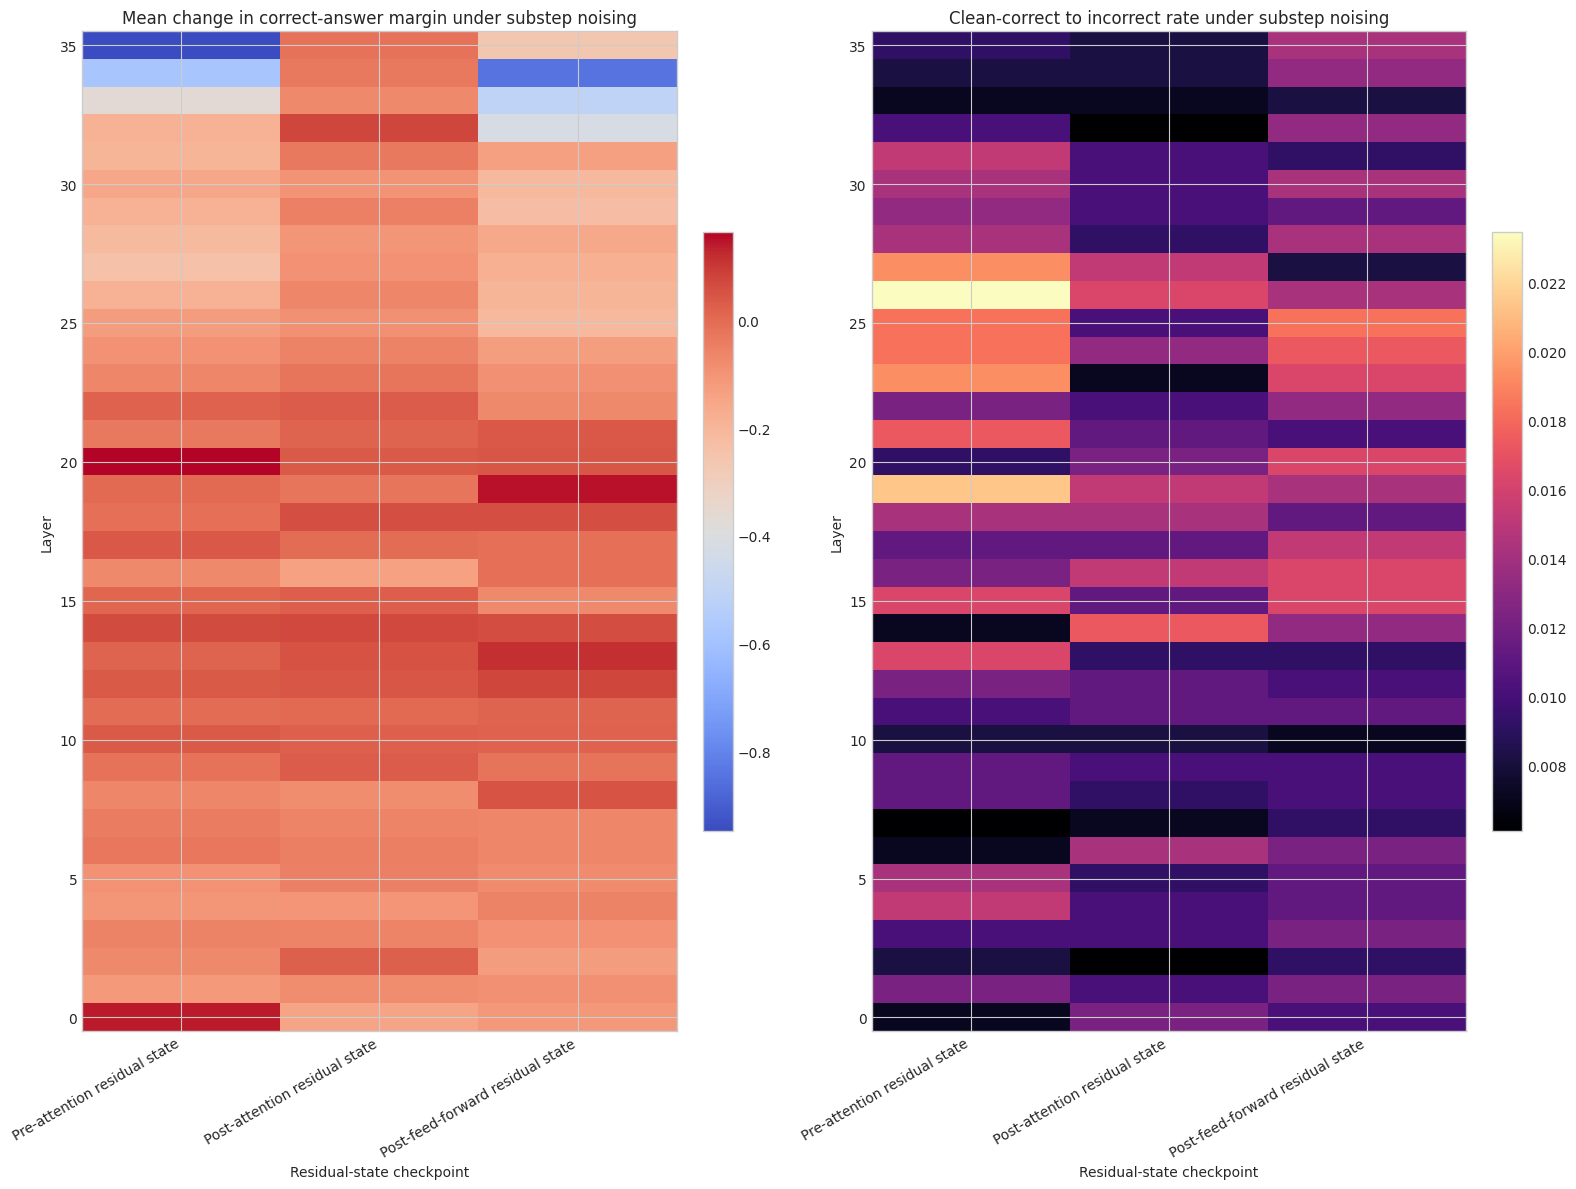

In [10]:
substep_order = ["pre_attn", "post_attn", "post_mlp"]
substep_labels = [substep_display_names[s] for s in substep_order]

def pivot_substep_metric(metric_name):
    table = (
        substep_summary.pivot(index="layer_index_1based", columns="target_substep", values=metric_name)
        .reindex(columns=substep_order)
        .sort_index()
    )
    return table


margin_delta_heat = pivot_substep_metric("mean_correct_margin_delta")
break_rate_heat = pivot_substep_metric("clean_correct_break_rate")

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

im0 = axes[0].imshow(margin_delta_heat.to_numpy(), aspect="auto", origin="lower", cmap="coolwarm")
axes[0].set_title("Mean change in correct-answer margin under substep noising")
axes[0].set_xlabel("Residual-state checkpoint")
axes[0].set_ylabel("Layer")
axes[0].set_xticks(np.arange(len(substep_labels)))
axes[0].set_xticklabels(substep_labels, rotation=30, ha="right")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(break_rate_heat.to_numpy(), aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Clean-correct to incorrect rate under substep noising")
axes[1].set_xlabel("Residual-state checkpoint")
axes[1].set_ylabel("Layer")
axes[1].set_xticks(np.arange(len(substep_labels)))
axes[1].set_xticklabels(substep_labels, rotation=30, ha="right")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


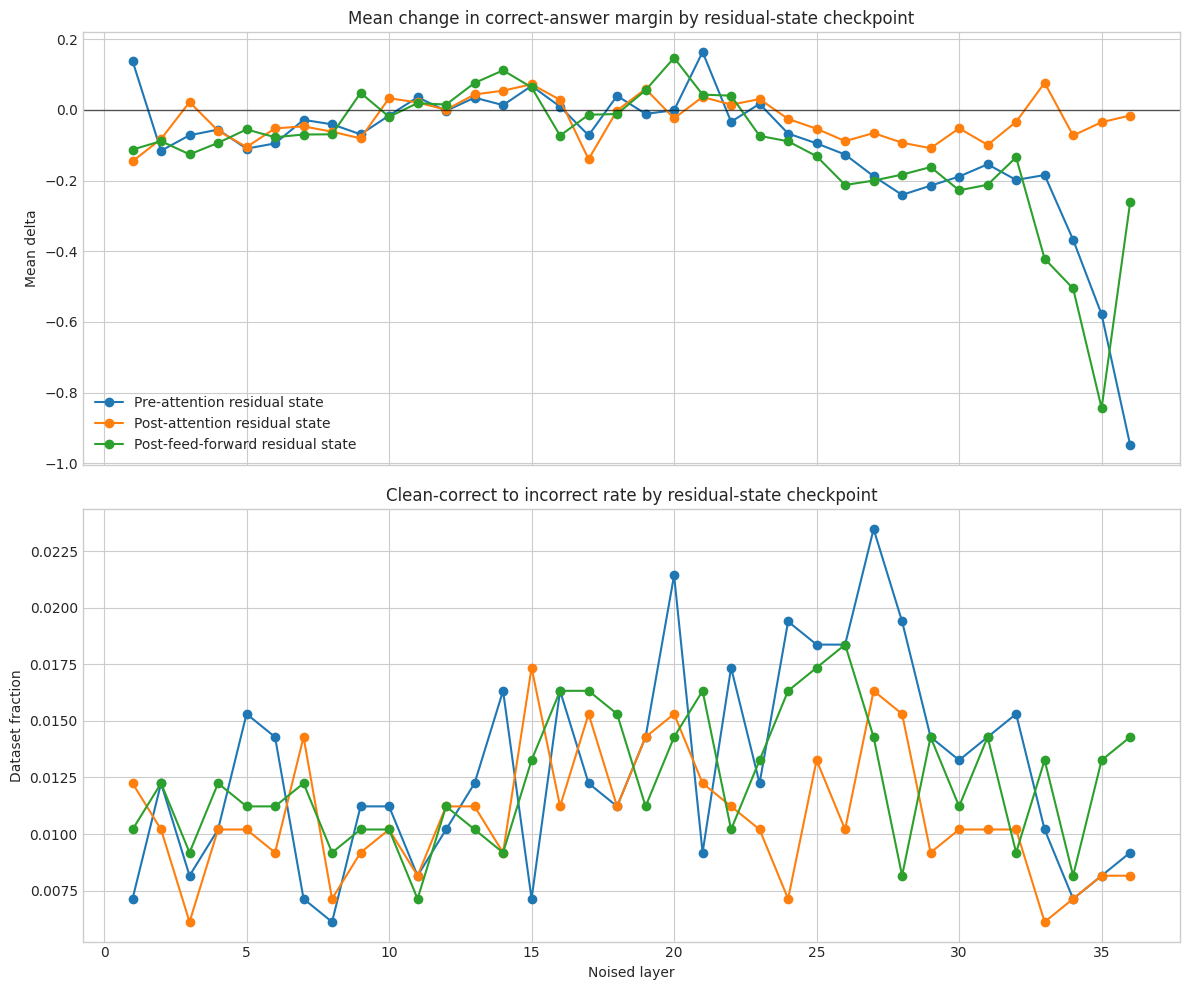

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for substep in substep_order:
    part = substep_summary.loc[substep_summary["target_substep"].eq(substep)].sort_values("layer_index_1based")
    label = substep_display_names[substep]
    axes[0].plot(part["layer_index_1based"], part["mean_correct_margin_delta"], marker="o", label=label)
    axes[1].plot(part["layer_index_1based"], part["clean_correct_break_rate"], marker="o", label=label)

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Mean change in correct-answer margin by residual-state checkpoint")
axes[0].legend()

axes[1].set_xlabel("Noised layer")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-correct to incorrect rate by residual-state checkpoint")

plt.tight_layout()
plt.show()


## Component Noising

Noise is injected into the output of one block component at a time.

- attention output
- feed-forward output


In [12]:
def run_component_noising_scan(frame, noise_scale):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc="component noising"):
        for component_idx, target_component in enumerate(["attention_output", "feed_forward_output"]):
            torch.manual_seed(SEED + 10000 * (target_layer + 1) + component_idx)
            current_state = {}
            layer = decoder_layers[target_layer]

            if target_component == "attention_output":
                if not hasattr(layer, "self_attn"):
                    raise ValueError("Expected self_attn on decoder layer.")

                def hook_fn(module, args, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    if isinstance(output, tuple):
                        return (hidden_out,) + output[1:]
                    return hidden_out

                handle = layer.self_attn.register_forward_hook(hook_fn)

            else:
                if not hasattr(layer, "mlp"):
                    raise ValueError("Expected mlp on decoder layer.")

                def hook_fn(module, args, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    if isinstance(output, tuple):
                        return (hidden_out,) + output[1:]
                    return hidden_out

                handle = layer.mlp.register_forward_hook(hook_fn)

            try:
                for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                    batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                    decision_pos = batch_cpu.pop("decision_pos")
                    batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                    decision_pos = decision_pos.to(model.device)
                    true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                    current_state["decision_pos"] = decision_pos

                    with torch.no_grad():
                        out = model(**batch, return_dict=True, use_cache=False)

                    row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                    final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                    pred_idx, correct_margin = compute_choice_metrics(final_logits, true_choice_idx)
                    noised_is_correct = pred_idx.eq(true_choice_idx.detach().cpu())

                    for bi in range(len(batch_df)):
                        rows.append(
                            {
                                "example_id": batch_df.loc[bi, "example_id"],
                                "target_layer": int(target_layer),
                                "target_component": target_component,
                                "noise_scale": float(noise_scale),
                                "noised_prediction_idx": int(pred_idx[bi].item()),
                                "noised_prediction": LETTERS[int(pred_idx[bi].item())],
                                "noised_correct_margin": float(correct_margin[bi].item()),
                                "noised_is_correct": bool(noised_is_correct[bi].item()),
                            }
                        )
            finally:
                handle.remove()

    return pd.DataFrame(rows)


component_df = run_component_noising_scan(eval_rows, MAIN_NOISE_SCALE)
component_df = component_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_correct_margin", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
component_df["prediction_preserved"] = component_df["noised_prediction_idx"].eq(component_df["clean_prediction_idx"])
component_df["correct_margin_delta"] = component_df["noised_correct_margin"] - component_df["clean_correct_margin"]
component_df["clean_correct_broken"] = component_df["clean_is_correct"] & (~component_df["noised_is_correct"])

component_summary = intervention_summary(component_df, ["target_layer", "target_component"])
component_summary["layer_index_1based"] = component_summary["target_layer"] + 1
component_summary["target_component_label"] = component_summary["target_component"].map(component_display_names)

display(component_summary.head(12).round(4))


component noising: 100%|██████████| 36/36 [29:16<00:00, 48.79s/it]


,target_layer,target_component,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based,target_component_label
0,0,attention_output,-0.1148,0.9730,0.8026,0.0122,0.9878,1,Attention output
1,0,feed_forward_output,-0.0756,0.9803,0.7961,0.0133,0.9867,1,Feed-forward output
2,1,attention_output,-0.0228,0.9853,0.8010,0.0071,0.9929,2,Attention output
3,1,feed_forward_output,0.0187,0.9861,0.8026,0.0061,0.9939,2,Feed-forward output
4,2,attention_output,0.0118,0.9836,0.8002,0.0092,0.9908,3,Attention output
5,2,feed_forward_output,-0.0046,0.9812,0.8018,0.0092,0.9908,3,Feed-forward output
6,3,attention_output,-0.0246,0.9844,0.8026,0.0071,0.9929,4,Attention output
7,3,feed_forward_output,0.0036,0.9844,0.8010,0.0082,0.9918,4,Feed-forward output
8,4,attention_output,0.0016,0.9828,0.8034,0.0071,0.9929,5,Attention output
9,4,feed_forward_output,0.0227,0.9861,0.8018,0.0071,0.9929,5,Feed-forward output


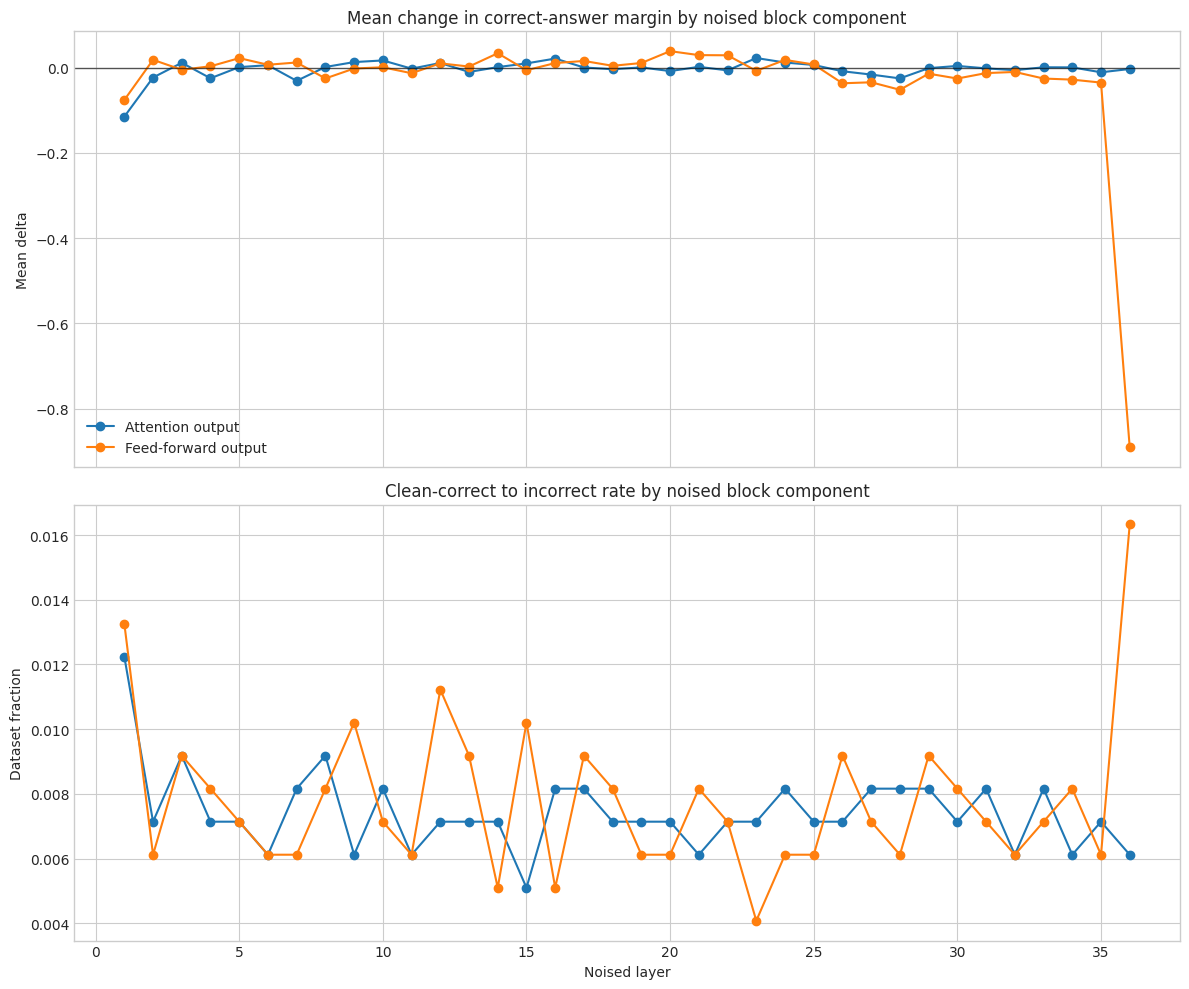

In [13]:
component_order = ["attention_output", "feed_forward_output"]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for component in component_order:
    part = component_summary.loc[component_summary["target_component"].eq(component)].sort_values("layer_index_1based")
    label = component_display_names[component]
    axes[0].plot(part["layer_index_1based"], part["mean_correct_margin_delta"], marker="o", label=label)
    axes[1].plot(part["layer_index_1based"], part["clean_correct_break_rate"], marker="o", label=label)

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Mean change in correct-answer margin by noised block component")
axes[0].legend()

axes[1].set_xlabel("Noised layer")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-correct to incorrect rate by noised block component")

plt.tight_layout()
plt.show()


In [14]:
component_average = (
    component_summary.groupby("target_component_label")[
        ["mean_correct_margin_delta", "clean_correct_break_rate", "prediction_preservation_rate"]
    ]
    .mean()
    .reset_index()
)

display(component_average.round(4))


,target_component_label,mean_correct_margin_delta,clean_correct_break_rate,prediction_preservation_rate
0,Attention output,-0.0039,0.0074,0.9839
1,Feed-forward output,-0.0281,0.0078,0.9825


## Dose-Response

Repeated layer-output noising scans over multiple noise scales.


In [15]:
dose_response_parts = []

for noise_scale in DOSE_RESPONSE_SCALES:
    part = run_layer_output_noising_scan(
        eval_rows,
        noise_scale,
        f"layer-output noising scale={noise_scale}",
    )
    part["noise_scale"] = float(noise_scale)
    dose_response_parts.append(part)

dose_response_df = pd.concat(dose_response_parts, ignore_index=True)
dose_response_df = dose_response_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_correct_margin", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
dose_response_df["prediction_preserved"] = dose_response_df["noised_prediction_idx"].eq(dose_response_df["clean_prediction_idx"])
dose_response_df["correct_margin_delta"] = dose_response_df["noised_correct_margin"] - dose_response_df["clean_correct_margin"]
dose_response_df["clean_correct_broken"] = dose_response_df["clean_is_correct"] & (~dose_response_df["noised_is_correct"])

dose_response_summary = intervention_summary(dose_response_df, ["noise_scale", "target_layer"])
dose_response_summary["layer_index_1based"] = dose_response_summary["target_layer"] + 1

display(dose_response_summary.head(12).round(4))


layer-output noising scale=0.5: 100%|██████████| 36/36 [14:43<00:00, 24.54s/it]


,noise_scale,target_layer,mean_correct_margin_delta,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based
0,0.05,0,0.0063,0.9812,0.8026,0.0082,0.9918,1
1,0.05,1,-0.0129,0.9836,0.8018,0.0071,0.9929,2
2,0.05,2,0.0018,0.9828,0.8010,0.0071,0.9929,3
3,0.05,3,0.0055,0.9844,0.8018,0.0071,0.9929,4
4,0.05,4,0.0153,0.9844,0.8010,0.0082,0.9918,5
5,0.05,5,0.0072,0.9844,0.8018,0.0071,0.9929,6
6,0.05,6,0.0166,0.9820,0.8010,0.0092,0.9908,7
7,0.05,7,0.0061,0.9836,0.8034,0.0071,0.9929,8
8,0.05,8,0.0103,0.9844,0.8018,0.0071,0.9929,9
9,0.05,9,-0.0031,0.9853,0.8018,0.0071,0.9929,10


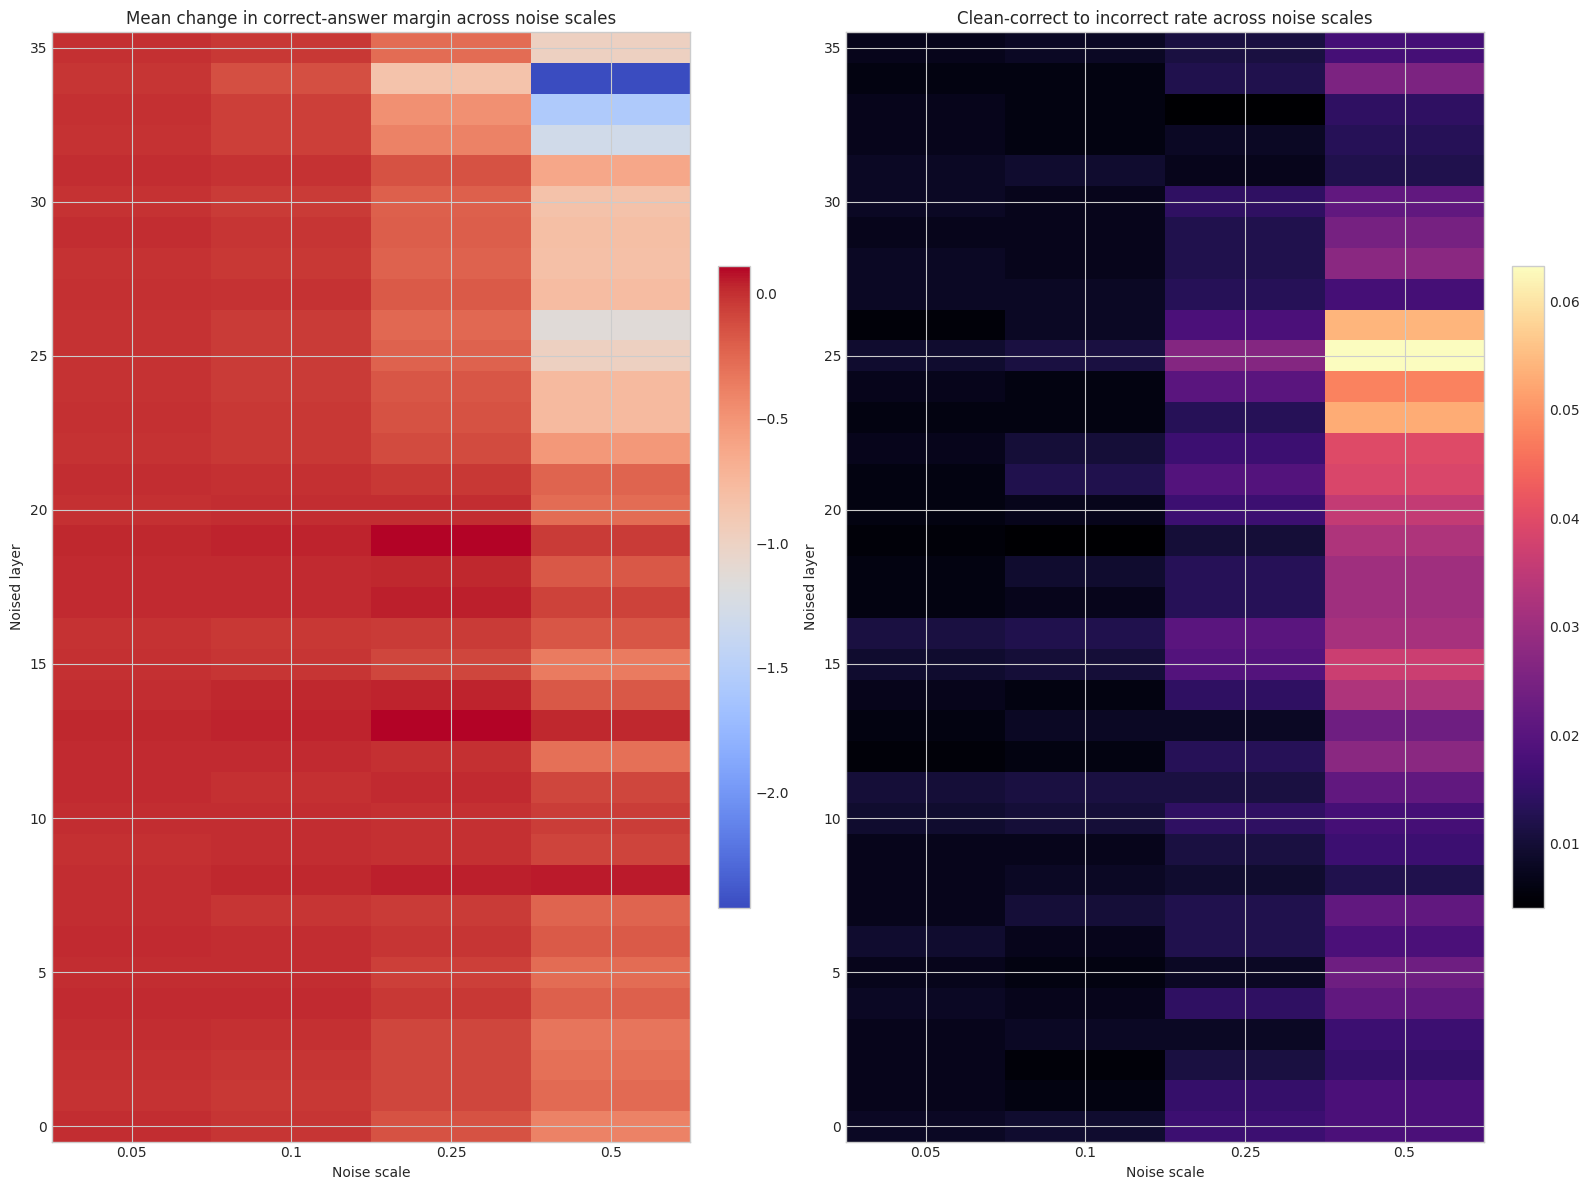

In [16]:
def pivot_dose_metric(metric_name):
    table = (
        dose_response_summary.pivot(index="layer_index_1based", columns="noise_scale", values=metric_name)
        .sort_index()
    )
    return table


dose_margin_delta = pivot_dose_metric("mean_correct_margin_delta")
dose_break_rate = pivot_dose_metric("clean_correct_break_rate")

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

im0 = axes[0].imshow(dose_margin_delta.to_numpy(), aspect="auto", origin="lower", cmap="coolwarm")
axes[0].set_title("Mean change in correct-answer margin across noise scales")
axes[0].set_xlabel("Noise scale")
axes[0].set_ylabel("Noised layer")
axes[0].set_xticks(np.arange(len(dose_margin_delta.columns)))
axes[0].set_xticklabels([str(x) for x in dose_margin_delta.columns])
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dose_break_rate.to_numpy(), aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Clean-correct to incorrect rate across noise scales")
axes[1].set_xlabel("Noise scale")
axes[1].set_ylabel("Noised layer")
axes[1].set_xticks(np.arange(len(dose_break_rate.columns)))
axes[1].set_xticklabels([str(x) for x in dose_break_rate.columns])
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

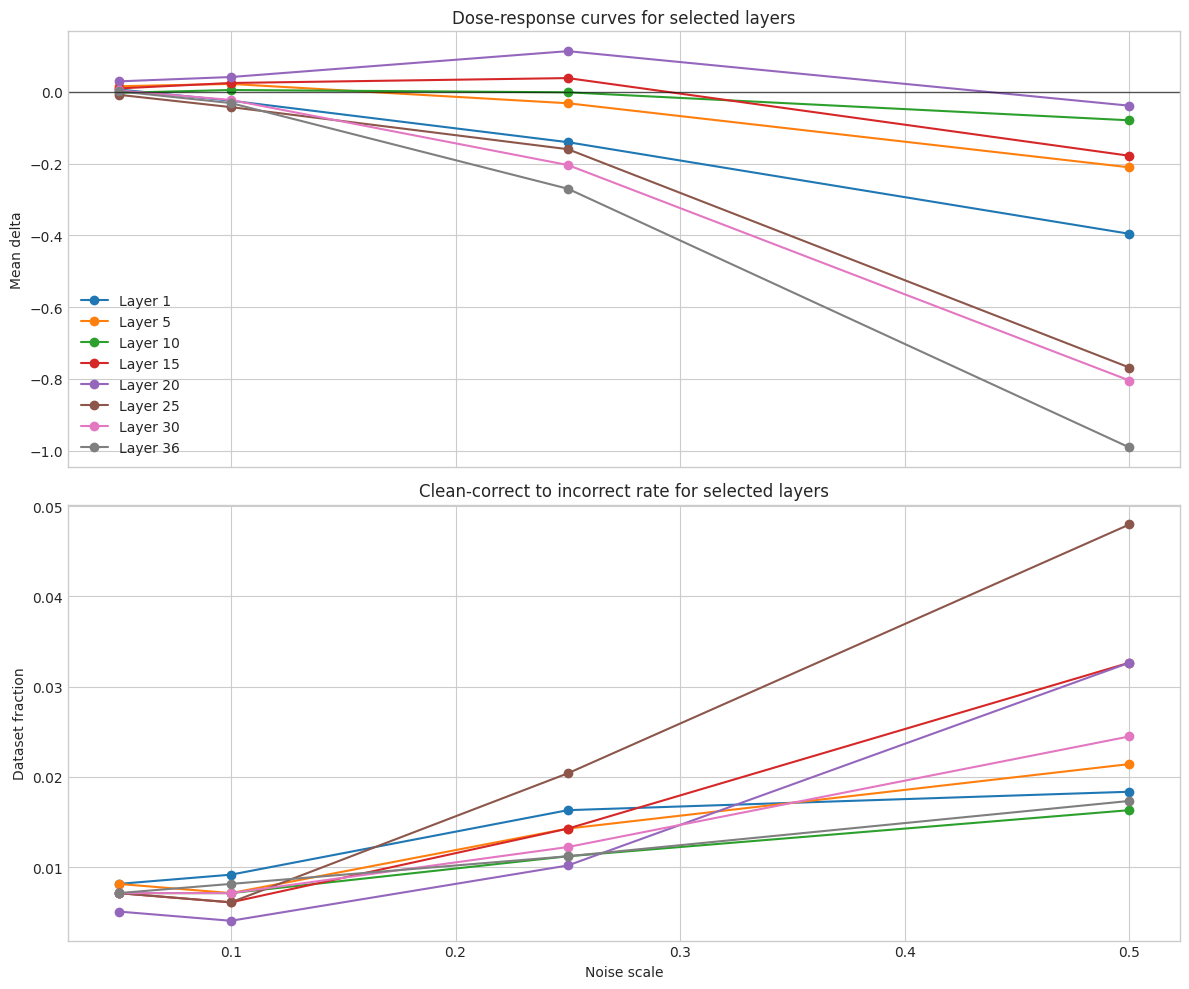

In [24]:
selected_layers = sorted({1, 5, 10, 15, 20, 25, 30, L})
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for layer_index_1based in selected_layers:
    part = dose_response_summary.loc[dose_response_summary["layer_index_1based"].eq(layer_index_1based)].sort_values("noise_scale")
    axes[0].plot(part["noise_scale"], part["mean_correct_margin_delta"], marker="o", label=f"Layer {layer_index_1based}")
    axes[1].plot(part["noise_scale"], part["clean_correct_break_rate"], marker="o", label=f"Layer {layer_index_1based}")

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Dose-response curves for selected layers")
axes[0].legend()

axes[1].set_xlabel("Noise scale")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-correct to incorrect rate for selected layers")

plt.tight_layout()
plt.show()